# NumPy Foundations for Deep Learning

## A Zero-to-Hero Guide for Neural Network Prerequisites

---

**Welcome!** This notebook will teach you NumPy from the ground up, with every concept directly connected to deep learning applications. By the end, you'll have the mathematical and programming foundation needed to understand how neural networks work.

### What You'll Learn

| Section | NumPy Concept | Deep Learning Connection |
|---------|--------------|-------------------------|
| 1 | Arrays & Shapes | Tensors, Data Representation |
| 2 | Indexing & Slicing | Batch Processing, Feature Selection |
| 3 | Element-wise Operations | Activation Functions |
| 4 | Broadcasting | Bias Addition, Normalization |
| 5 | Matrix Multiplication | Forward Pass, Layer Computation |
| 6 | Statistics & Aggregation | Loss Functions, Batch Normalization |
| 7 | Reshaping | Flattening Images, Tensor Manipulation |
| 8 | Random Generation | Weight Initialization, Dropout |
| 9 | Vectorization | Efficient Neural Network Training |
| 10 | Mini Neural Network | Putting It All Together |

---

In [1]:
# Setup - Run this cell first!
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import matplotlib.gridspec as gridspec
from mpl_toolkits.mplot3d import Axes3D

# Beautiful plot settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# For reproducibility
np.random.seed(42)

print("NumPy version:", np.__version__)
print("Setup complete!")

NumPy version: 2.2.6
Setup complete!


---

# Section 1: Arrays - The Building Blocks of Deep Learning

## Why NumPy Arrays?

In deep learning, ALL data is represented as **multi-dimensional arrays** (called **tensors**):

- **Images**: 3D arrays (height x width x channels)
- **Text**: 2D arrays (sequence_length x embedding_dim)
- **Batches**: Add one more dimension for multiple samples
- **Weights**: 2D arrays connecting layers

NumPy arrays are the foundation that PyTorch tensors and TensorFlow tensors are built upon!

## 1.1 Creating Arrays

Let's start with the basics - creating arrays in different ways.

In [2]:
# From a Python list - simplest way
a = np.array([1, 2, 3, 4, 5])
print("1D Array (Vector):")
print(a)
print(f"Shape: {a.shape}")
print(f"Dimensions: {a.ndim}")
print()

1D Array (Vector):
[1 2 3 4 5]
Shape: (5,)
Dimensions: 1



In [3]:
# 2D Array (Matrix) - like a spreadsheet or image
b = np.array([[1, 2, 3],
              [4, 5, 6]])
print("2D Array (Matrix):")
print(b)
print(f"Shape: {b.shape}  <- (rows, columns)")
print(f"Dimensions: {b.ndim}")
print()

2D Array (Matrix):
[[1 2 3]
 [4 5 6]]
Shape: (2, 3)  <- (rows, columns)
Dimensions: 2



In [4]:
# 3D Array - like a stack of matrices (or RGB image)
c = np.array([[[1, 2], [3, 4]],
              [[5, 6], [7, 8]],
              [[9, 10], [11, 12]]])
print("3D Array (Tensor):")
print(c)
print(f"Shape: {c.shape}  <- (depth, rows, columns)")
print(f"Dimensions: {c.ndim}")

3D Array (Tensor):
[[[ 1  2]
  [ 3  4]]

 [[ 5  6]
  [ 7  8]]

 [[ 9 10]
  [11 12]]]
Shape: (3, 2, 2)  <- (depth, rows, columns)
Dimensions: 3


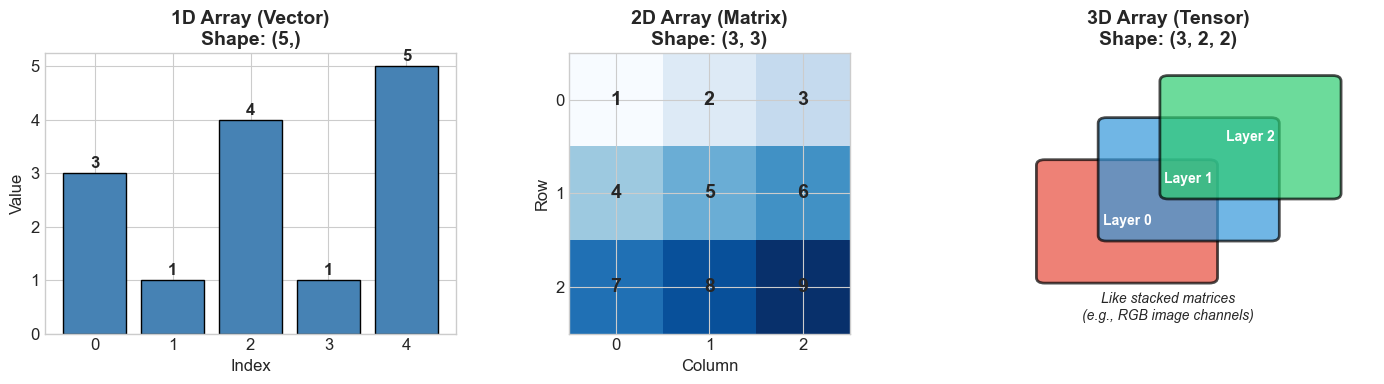

In [5]:
# Visualize array dimensions
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# 1D - Vector
ax1 = axes[0]
vector = np.array([3, 1, 4, 1, 5])
ax1.bar(range(len(vector)), vector, color='steelblue', edgecolor='black')
ax1.set_title('1D Array (Vector)\nShape: (5,)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Index')
ax1.set_ylabel('Value')
for i, v in enumerate(vector):
    ax1.text(i, v + 0.1, str(v), ha='center', fontweight='bold')

# 2D - Matrix
ax2 = axes[1]
matrix = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
im = ax2.imshow(matrix, cmap='Blues')
ax2.set_title('2D Array (Matrix)\nShape: (3, 3)', fontsize=14, fontweight='bold')
for i in range(3):
    for j in range(3):
        ax2.text(j, i, matrix[i, j], ha='center', va='center', fontsize=14, fontweight='bold')
ax2.set_xticks(range(3))
ax2.set_yticks(range(3))
ax2.set_xlabel('Column')
ax2.set_ylabel('Row')

# 3D - Tensor visualization
ax3 = axes[2]
ax3.axis('off')
ax3.set_title('3D Array (Tensor)\nShape: (3, 2, 2)', fontsize=14, fontweight='bold')

# Draw stacked matrices
colors = ['#e74c3c', '#3498db', '#2ecc71']
for idx, (color, offset) in enumerate(zip(colors, [0, 0.15, 0.3])):
    rect = FancyBboxPatch((0.2 + offset, 0.2 + offset), 0.4, 0.4,
                          boxstyle="round,pad=0.02",
                          facecolor=color, alpha=0.7, edgecolor='black', linewidth=2)
    ax3.add_patch(rect)
    ax3.text(0.4 + offset, 0.4 + offset, f'Layer {idx}', ha='center', va='center',
             fontsize=10, fontweight='bold', color='white')

ax3.set_xlim(0, 1)
ax3.set_ylim(0, 1)
ax3.text(0.5, 0.05, 'Like stacked matrices\n(e.g., RGB image channels)',
         ha='center', fontsize=10, style='italic')

plt.tight_layout()
plt.show()

## 1.2 Special Array Creation Functions

These are used constantly in deep learning for initialization!

In [6]:
# Zeros - used for bias initialization
zeros = np.zeros((3, 4))
print("Zeros (3x4):")
print(zeros)
print("Deep Learning Use: Initialize biases to zero\n")

# Ones - used for masks, scaling
ones = np.ones((2, 3))
print("Ones (2x3):")
print(ones)
print("Deep Learning Use: Attention masks, gradient scaling\n")

# Identity matrix - used in residual connections
identity = np.eye(4)
print("Identity (4x4):")
print(identity)
print("Deep Learning Use: Skip connections (ResNet), orthogonal initialization")

Zeros (3x4):
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]
Deep Learning Use: Initialize biases to zero

Ones (2x3):
[[1. 1. 1.]
 [1. 1. 1.]]
Deep Learning Use: Attention masks, gradient scaling

Identity (4x4):
[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]
Deep Learning Use: Skip connections (ResNet), orthogonal initialization


In [7]:
# Ranges - useful for creating sequences
print("np.arange(0, 10, 2):")
print(np.arange(0, 10, 2))  # start, stop, step
print("Deep Learning Use: Creating position encodings\n")

print("np.linspace(0, 1, 5):")
print(np.linspace(0, 1, 5))  # start, stop, num_points
print("Deep Learning Use: Learning rate schedules, interpolation")

np.arange(0, 10, 2):
[0 2 4 6 8]
Deep Learning Use: Creating position encodings

np.linspace(0, 1, 5):
[0.   0.25 0.5  0.75 1.  ]
Deep Learning Use: Learning rate schedules, interpolation


## 1.3 Data Types (dtypes)

**Critical for Deep Learning**: The dtype affects memory usage, speed, and precision!

In [8]:
# Different data types
int_array = np.array([1, 2, 3], dtype=np.int32)
float32_array = np.array([1, 2, 3], dtype=np.float32)
float64_array = np.array([1, 2, 3], dtype=np.float64)

print(f"int32:   {int_array}, dtype={int_array.dtype}, bytes per element={int_array.itemsize}")
print(f"float32: {float32_array}, dtype={float32_array.dtype}, bytes per element={float32_array.itemsize}")
print(f"float64: {float64_array}, dtype={float64_array.dtype}, bytes per element={float64_array.itemsize}")

int32:   [1 2 3], dtype=int32, bytes per element=4
float32: [1. 2. 3.], dtype=float32, bytes per element=4
float64: [1. 2. 3.], dtype=float64, bytes per element=8


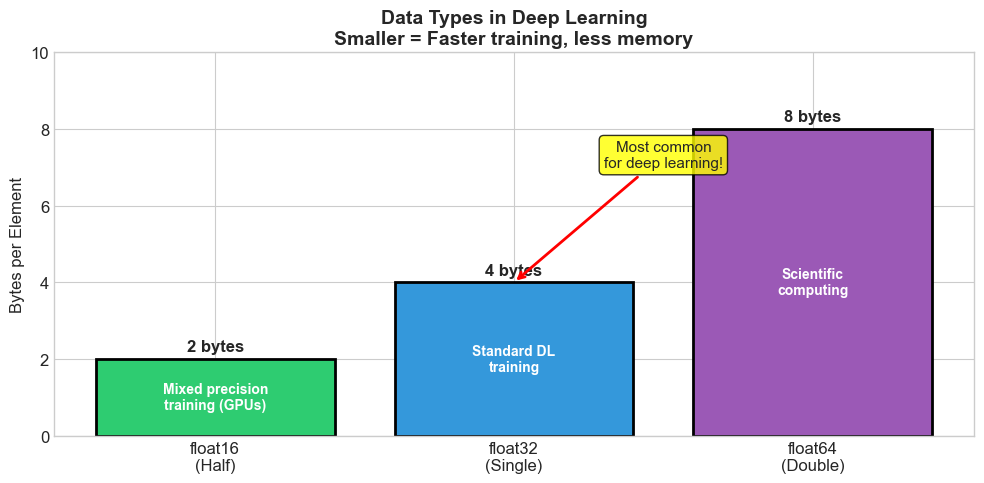

In [9]:
# Visualize dtype memory usage for deep learning
fig, ax = plt.subplots(figsize=(10, 5))

dtypes = ['float16\n(Half)', 'float32\n(Single)', 'float64\n(Double)']
bytes_per = [2, 4, 8]
colors = ['#2ecc71', '#3498db', '#9b59b6']
uses = ['Mixed precision\ntraining (GPUs)', 'Standard DL\ntraining', 'Scientific\ncomputing']

bars = ax.bar(dtypes, bytes_per, color=colors, edgecolor='black', linewidth=2)

for bar, use in zip(bars, uses):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.2,
            f'{int(height)} bytes', ha='center', fontweight='bold', fontsize=12)
    ax.text(bar.get_x() + bar.get_width()/2., height/2,
            use, ha='center', va='center', fontsize=10, color='white', fontweight='bold')

ax.set_ylabel('Bytes per Element', fontsize=12)
ax.set_title('Data Types in Deep Learning\nSmaller = Faster training, less memory', fontsize=14, fontweight='bold')
ax.set_ylim(0, 10)

# Add annotation
ax.annotate('Most common\nfor deep learning!', xy=(1, 4), xytext=(1.5, 7),
            fontsize=11, ha='center',
            arrowprops=dict(arrowstyle='->', color='red', lw=2),
            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.8))

plt.tight_layout()
plt.show()

### Deep Learning Connection: Tensor Shapes in Neural Networks

Understanding shapes is **CRUCIAL**. Let's see real examples:

In [10]:
# Real deep learning tensor shapes
print("Common Tensor Shapes in Deep Learning:")
print("=" * 50)

# Batch of grayscale images (like MNIST)
mnist_batch = np.zeros((32, 28, 28))  # 32 images, 28x28 pixels
print(f"\nMNIST batch shape: {mnist_batch.shape}")
print("  -> (batch_size, height, width)")

# Batch of color images (like CIFAR-10)
cifar_batch = np.zeros((32, 32, 32, 3))  # 32 images, 32x32 pixels, RGB
print(f"\nCIFAR-10 batch shape: {cifar_batch.shape}")
print("  -> (batch_size, height, width, channels)")

# Weight matrix for fully connected layer
weights = np.zeros((784, 256))  # 784 inputs -> 256 outputs
print(f"\nDense layer weights shape: {weights.shape}")
print("  -> (input_features, output_features)")

# Sequence data (like text)
text_batch = np.zeros((16, 100, 512))  # 16 sequences, length 100, embedding dim 512
print(f"\nText batch shape: {text_batch.shape}")
print("  -> (batch_size, sequence_length, embedding_dim)")

Common Tensor Shapes in Deep Learning:

MNIST batch shape: (32, 28, 28)
  -> (batch_size, height, width)

CIFAR-10 batch shape: (32, 32, 32, 3)
  -> (batch_size, height, width, channels)

Dense layer weights shape: (784, 256)
  -> (input_features, output_features)

Text batch shape: (16, 100, 512)
  -> (batch_size, sequence_length, embedding_dim)


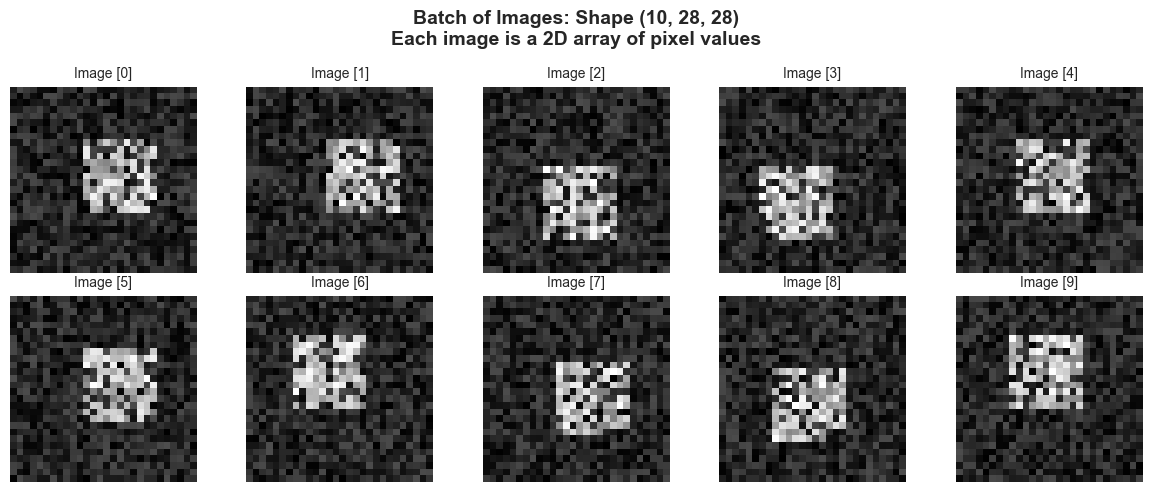


Batch shape: (10, 28, 28)
Single image shape: (28, 28)
Total pixels in batch: 7,840


In [11]:
# Visualize a real MNIST-like image batch
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('Batch of Images: Shape (10, 28, 28)\nEach image is a 2D array of pixel values',
             fontsize=14, fontweight='bold')

# Create fake digit-like patterns
batch = np.random.rand(10, 28, 28) * 0.3  # background noise
for i in range(10):
    # Add some structure to make them look digit-like
    center_x, center_y = 14 + np.random.randint(-3, 4), 14 + np.random.randint(-3, 4)
    for dx in range(-5, 6):
        for dy in range(-5, 6):
            if np.random.rand() > 0.3:
                x, y = center_x + dx, center_y + dy
                if 0 <= x < 28 and 0 <= y < 28:
                    batch[i, y, x] = np.random.rand() * 0.5 + 0.5

for idx, ax in enumerate(axes.flat):
    ax.imshow(batch[idx], cmap='gray')
    ax.set_title(f'Image [{idx}]', fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

print(f"\nBatch shape: {batch.shape}")
print(f"Single image shape: {batch[0].shape}")
print(f"Total pixels in batch: {batch.size:,}")

## Quick Check: Understanding Shapes

Test your understanding!

In [12]:
# Exercise: Predict the shapes before running!
a = np.zeros((3, 4, 5))
b = np.ones((2,))
c = np.eye(3)

print("Predict these shapes, then check:")
print(f"a.shape = {a.shape}  <- 3D tensor with ? elements")
print(f"b.shape = {b.shape}  <- 1D vector")
print(f"c.shape = {c.shape}  <- 2D identity matrix")
print(f"\nTotal elements: a={a.size}, b={b.size}, c={c.size}")

Predict these shapes, then check:
a.shape = (3, 4, 5)  <- 3D tensor with ? elements
b.shape = (2,)  <- 1D vector
c.shape = (3, 3)  <- 2D identity matrix

Total elements: a=60, b=2, c=9


---

# Section 2: Indexing and Slicing

## Why It Matters for Deep Learning

- **Batch selection**: Get specific samples from your dataset
- **Feature extraction**: Select specific channels or dimensions
- **Train/test splits**: Divide data for training and validation
- **Attention mechanisms**: Select relevant parts of sequences

## 2.1 Basic Indexing (1D Arrays)

In [13]:
arr = np.array([10, 20, 30, 40, 50, 60, 70, 80, 90])
print("Array:", arr)
print(f"Length: {len(arr)}")
print()

# Positive indexing (from start)
print(f"arr[0] = {arr[0]}   <- First element")
print(f"arr[3] = {arr[3]}   <- Fourth element")
print()

# Negative indexing (from end)
print(f"arr[-1] = {arr[-1]}  <- Last element")
print(f"arr[-2] = {arr[-2]}  <- Second to last")

Array: [10 20 30 40 50 60 70 80 90]
Length: 9

arr[0] = 10   <- First element
arr[3] = 40   <- Fourth element

arr[-1] = 90  <- Last element
arr[-2] = 80  <- Second to last


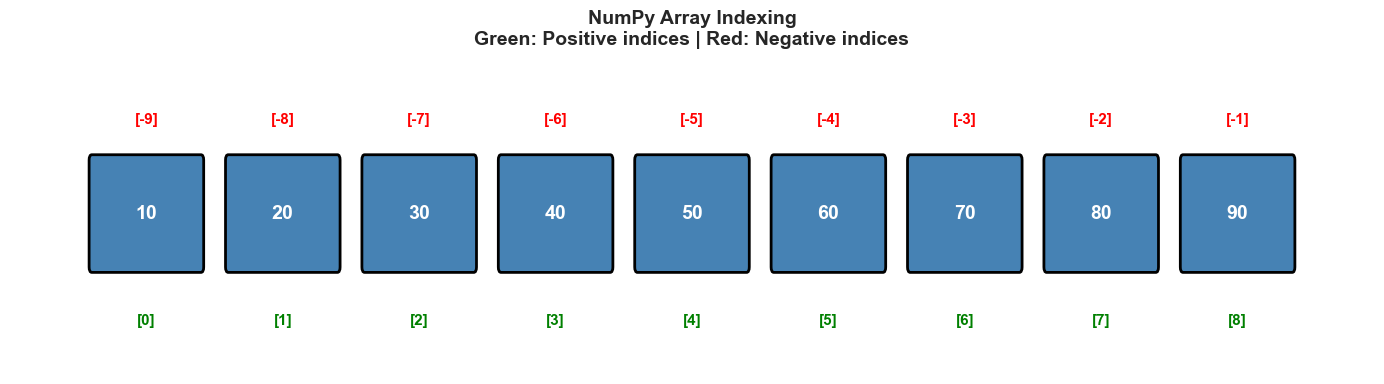

In [14]:
# Visualize indexing
fig, ax = plt.subplots(figsize=(14, 4))

arr = np.array([10, 20, 30, 40, 50, 60, 70, 80, 90])
x_pos = np.arange(len(arr))

# Draw boxes for each element
for i, (x, val) in enumerate(zip(x_pos, arr)):
    rect = FancyBboxPatch((x - 0.4, 0.3), 0.8, 0.4,
                          boxstyle="round,pad=0.02",
                          facecolor='steelblue', edgecolor='black', linewidth=2)
    ax.add_patch(rect)
    ax.text(x, 0.5, str(val), ha='center', va='center', fontsize=14, fontweight='bold', color='white')

    # Positive index
    ax.text(x, 0.1, f'[{i}]', ha='center', va='center', fontsize=11, color='green', fontweight='bold')

    # Negative index
    ax.text(x, 0.85, f'[{i - len(arr)}]', ha='center', va='center', fontsize=11, color='red', fontweight='bold')

ax.set_xlim(-1, len(arr))
ax.set_ylim(-0.1, 1.1)
ax.axis('off')
ax.set_title('NumPy Array Indexing\nGreen: Positive indices | Red: Negative indices', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 2.2 Slicing: `start:stop:step`

The slice syntax `[start:stop:step]` is incredibly powerful!

In [15]:
arr = np.array([10, 20, 30, 40, 50, 60, 70, 80, 90])
print("Original:", arr)
print()

# Basic slicing
print(f"arr[2:5]   = {arr[2:5]}      <- Elements 2,3,4 (stop is exclusive!)")
print(f"arr[:4]    = {arr[:4]}    <- First 4 elements")
print(f"arr[5:]    = {arr[5:]}    <- From index 5 to end")
print(f"arr[::2]   = {arr[::2]}   <- Every 2nd element")
print(f"arr[::-1]  = {arr[::-1]}  <- Reversed!")

Original: [10 20 30 40 50 60 70 80 90]

arr[2:5]   = [30 40 50]      <- Elements 2,3,4 (stop is exclusive!)
arr[:4]    = [10 20 30 40]    <- First 4 elements
arr[5:]    = [60 70 80 90]    <- From index 5 to end
arr[::2]   = [10 30 50 70 90]   <- Every 2nd element
arr[::-1]  = [90 80 70 60 50 40 30 20 10]  <- Reversed!


In [16]:
# Deep Learning Example: Train/Validation Split
print("Deep Learning Use Case: Train/Validation Split")
print("=" * 50)

# Simulate a dataset
dataset = np.arange(100)  # 100 samples
np.random.shuffle(dataset)  # Shuffle!

# 80/20 split
split_idx = int(0.8 * len(dataset))
train_data = dataset[:split_idx]
val_data = dataset[split_idx:]

print(f"Total samples: {len(dataset)}")
print(f"Training samples: {len(train_data)} (indices [:80])")
print(f"Validation samples: {len(val_data)} (indices [80:])")
print(f"\nFirst 10 training samples: {train_data[:10]}")

Deep Learning Use Case: Train/Validation Split
Total samples: 100
Training samples: 80 (indices [:80])
Validation samples: 20 (indices [80:])

First 10 training samples: [65 36  2 60 48 45 20  6 69 92]


## 2.3 Multi-dimensional Indexing

This is where it gets powerful for deep learning!

In [17]:
# Create a 2D array (matrix)
matrix = np.array([[1, 2, 3, 4],
                   [5, 6, 7, 8],
                   [9, 10, 11, 12]])

print("Matrix (3x4):")
print(matrix)
print(f"Shape: {matrix.shape}")
print()

# Accessing elements: [row, column]
print(f"matrix[0, 0] = {matrix[0, 0]}   <- Top-left")
print(f"matrix[1, 2] = {matrix[1, 2]}   <- Row 1, Column 2")
print(f"matrix[-1, -1] = {matrix[-1, -1]} <- Bottom-right")

Matrix (3x4):
[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]
Shape: (3, 4)

matrix[0, 0] = 1   <- Top-left
matrix[1, 2] = 7   <- Row 1, Column 2
matrix[-1, -1] = 12 <- Bottom-right


In [18]:
# Slicing rows and columns
print("Slicing Examples:")
print(f"matrix[0, :]   = {matrix[0, :]}      <- First row (all columns)")
print(f"matrix[:, 0]   = {matrix[:, 0]}          <- First column (all rows)")
print(f"matrix[0:2, 1:3] =\n{matrix[0:2, 1:3]}    <- Submatrix")

Slicing Examples:
matrix[0, :]   = [1 2 3 4]      <- First row (all columns)
matrix[:, 0]   = [1 5 9]          <- First column (all rows)
matrix[0:2, 1:3] =
[[2 3]
 [6 7]]    <- Submatrix


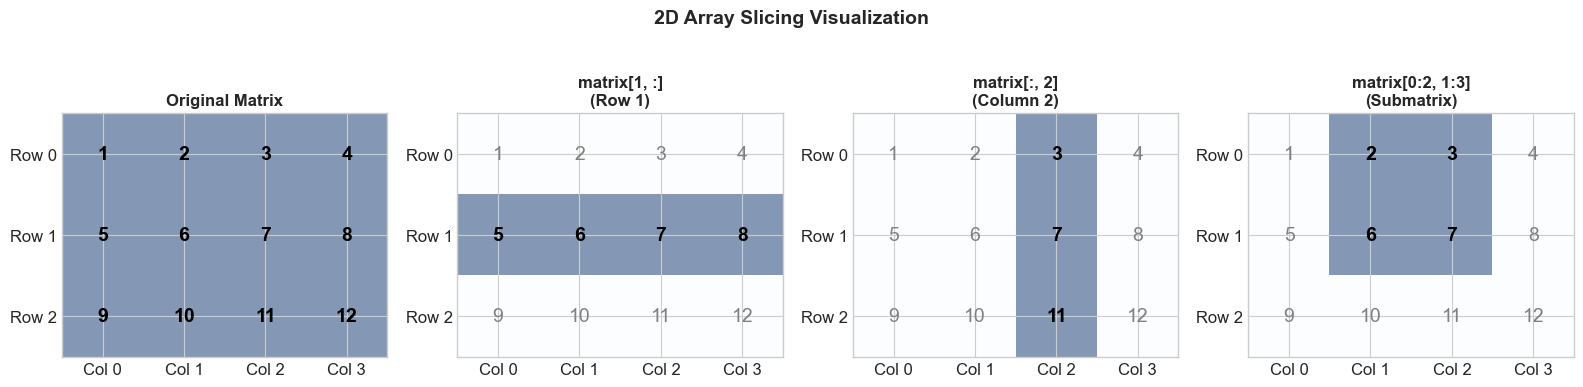

In [19]:
# Visualize 2D slicing
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

matrix = np.arange(1, 13).reshape(3, 4)

titles = ['Original Matrix', 'matrix[1, :]\n(Row 1)', 'matrix[:, 2]\n(Column 2)', 'matrix[0:2, 1:3]\n(Submatrix)']
data = [matrix, matrix[1:2, :], matrix[:, 2:3], matrix[0:2, 1:3]]
highlights = [None, (1, slice(None)), (slice(None), 2), (slice(0,2), slice(1,3))]

for ax, title, d, h in zip(axes, titles, data, highlights):
    # Show full matrix with highlight
    display = np.zeros_like(matrix, dtype=float)
    if h is None:
        display = matrix.astype(float)
        mask = np.ones_like(matrix)
    else:
        mask = np.zeros_like(matrix)
        mask[h] = 1
        display = matrix * mask

    ax.imshow(mask, cmap='Blues', alpha=0.5, vmin=0, vmax=1)

    for i in range(3):
        for j in range(4):
            color = 'black' if mask[i, j] else 'gray'
            weight = 'bold' if mask[i, j] else 'normal'
            ax.text(j, i, str(matrix[i, j]), ha='center', va='center',
                   fontsize=14, color=color, fontweight=weight)

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xticks(range(4))
    ax.set_yticks(range(3))
    ax.set_xticklabels(['Col 0', 'Col 1', 'Col 2', 'Col 3'])
    ax.set_yticklabels(['Row 0', 'Row 1', 'Row 2'])

plt.suptitle('2D Array Slicing Visualization', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Deep Learning Connection: Batch Processing

In [20]:
# Simulating batch processing in neural networks
print("Deep Learning Use Case: Mini-Batch Selection")
print("=" * 50)

# Create fake image dataset: 1000 images, 28x28 pixels
dataset = np.random.rand(1000, 28, 28)
labels = np.random.randint(0, 10, 1000)  # 10 classes

print(f"Dataset shape: {dataset.shape}")
print(f"Labels shape: {labels.shape}")

# Get a mini-batch of 32 samples
batch_size = 32
batch_idx = 0

start = batch_idx * batch_size
end = start + batch_size

batch_images = dataset[start:end]  # Shape: (32, 28, 28)
batch_labels = labels[start:end]   # Shape: (32,)

print(f"\nBatch {batch_idx}:")
print(f"  Images shape: {batch_images.shape}")
print(f"  Labels shape: {batch_labels.shape}")
print(f"  Labels: {batch_labels[:10]}... (first 10)")

Deep Learning Use Case: Mini-Batch Selection
Dataset shape: (1000, 28, 28)
Labels shape: (1000,)

Batch 0:
  Images shape: (32, 28, 28)
  Labels shape: (32,)
  Labels: [0 3 7 0 6 1 1 6 9 4]... (first 10)


## 2.4 Boolean Indexing (Masking)

Select elements based on conditions - super useful for filtering data!

In [21]:
arr = np.array([1, -2, 3, -4, 5, -6, 7, -8, 9])
print("Array:", arr)
print()

# Create boolean mask
mask = arr > 0
print(f"Mask (arr > 0): {mask}")
print(f"Positive values: {arr[mask]}")
print()

# Multiple conditions
mask2 = (arr > 0) & (arr < 6)  # Note: use & not 'and'
print(f"Values between 0 and 6: {arr[mask2]}")

Array: [ 1 -2  3 -4  5 -6  7 -8  9]

Mask (arr > 0): [ True False  True False  True False  True False  True]
Positive values: [1 3 5 7 9]

Values between 0 and 6: [1 3 5]


Deep Learning Use Case: ReLU Activation
Before ReLU: [-2.5  1.2 -0.5  3.1 -1.8  0.7 -0.1  2.4]
After ReLU:  [0.  1.2 0.  3.1 0.  0.7 0.  2.4]


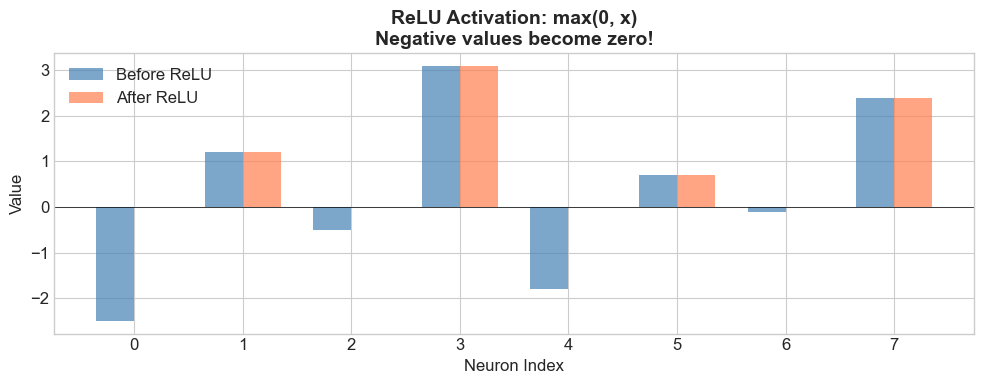

In [22]:
# Deep Learning Example: ReLU activation using boolean indexing!
print("Deep Learning Use Case: ReLU Activation")
print("=" * 50)

# Simulate layer output (before activation)
z = np.array([-2.5, 1.2, -0.5, 3.1, -1.8, 0.7, -0.1, 2.4])
print(f"Before ReLU: {z}")

# ReLU: max(0, x) - implemented with boolean indexing
relu_output = z.copy()
relu_output[relu_output < 0] = 0  # Set negatives to zero
print(f"After ReLU:  {relu_output}")

# Visualize
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(z))
width = 0.35

bars1 = ax.bar(x - width/2, z, width, label='Before ReLU', color='steelblue', alpha=0.7)
bars2 = ax.bar(x + width/2, relu_output, width, label='After ReLU', color='coral', alpha=0.7)

ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.set_xlabel('Neuron Index')
ax.set_ylabel('Value')
ax.set_title('ReLU Activation: max(0, x)\nNegative values become zero!', fontsize=14, fontweight='bold')
ax.legend()
ax.set_xticks(x)

plt.tight_layout()
plt.show()

## 2.5 Fancy Indexing

Use arrays of indices to select specific elements.

In [23]:
arr = np.array([10, 20, 30, 40, 50, 60, 70, 80, 90])
print("Array:", arr)

# Select specific indices
indices = np.array([0, 2, 5, 8])
print(f"Indices: {indices}")
print(f"Selected: {arr[indices]}")

Array: [10 20 30 40 50 60 70 80 90]
Indices: [0 2 5 8]
Selected: [10 30 60 90]


In [24]:
# Deep Learning Example: Embedding lookup
print("Deep Learning Use Case: Word Embedding Lookup")
print("=" * 50)

# Embedding matrix: 1000 words, 128-dimensional embeddings
vocab_size = 1000
embedding_dim = 128
embedding_matrix = np.random.randn(vocab_size, embedding_dim)

print(f"Embedding matrix shape: {embedding_matrix.shape}")

# A sentence as word indices
sentence = np.array([42, 156, 789, 23, 501])  # 5 word indices
print(f"Sentence (word indices): {sentence}")

# Look up embeddings for the sentence
sentence_embeddings = embedding_matrix[sentence]  # Fancy indexing!
print(f"Sentence embeddings shape: {sentence_embeddings.shape}")
print("  -> (num_words, embedding_dim)")

Deep Learning Use Case: Word Embedding Lookup
Embedding matrix shape: (1000, 128)
Sentence (word indices): [ 42 156 789  23 501]
Sentence embeddings shape: (5, 128)
  -> (num_words, embedding_dim)


---

# Section 3: Element-wise Operations

## The Foundation of Neural Network Computation

**Element-wise operations** apply the same operation to every element in an array. This is how:
- Activation functions work (apply sigmoid/ReLU to every neuron)
- Normalization works (subtract mean, divide by std from every value)
- Loss gradients are computed

Let's master these operations!

## 3.1 Arithmetic Operations

In [25]:
# Basic arithmetic - operates on every element!
a = np.array([1, 2, 3, 4, 5])
print("Array a:", a)
print()

print(f"a + 10  = {a + 10}   <- Add 10 to each element")
print(f"a * 2   = {a * 2}    <- Multiply each by 2")
print(f"a ** 2  = {a ** 2}   <- Square each element")
print(f"a / 2   = {a / 2}  <- Divide each by 2")

Array a: [1 2 3 4 5]

a + 10  = [11 12 13 14 15]   <- Add 10 to each element
a * 2   = [ 2  4  6  8 10]    <- Multiply each by 2
a ** 2  = [ 1  4  9 16 25]   <- Square each element
a / 2   = [0.5 1.  1.5 2.  2.5]  <- Divide each by 2


In [26]:
# Operations between two arrays (same shape)
a = np.array([1, 2, 3, 4])
b = np.array([5, 6, 7, 8])

print("Array a:", a)
print("Array b:", b)
print()

print(f"a + b = {a + b}   <- Add corresponding elements")
print(f"a * b = {a * b}   <- Multiply corresponding elements (Hadamard product)")
print(f"a - b = {a - b}  <- Subtract corresponding elements")
print(f"a / b = {a / b}  <- Divide corresponding elements")

Array a: [1 2 3 4]
Array b: [5 6 7 8]

a + b = [ 6  8 10 12]   <- Add corresponding elements
a * b = [ 5 12 21 32]   <- Multiply corresponding elements (Hadamard product)
a - b = [-4 -4 -4 -4]  <- Subtract corresponding elements
a / b = [0.2        0.33333333 0.42857143 0.5       ]  <- Divide corresponding elements


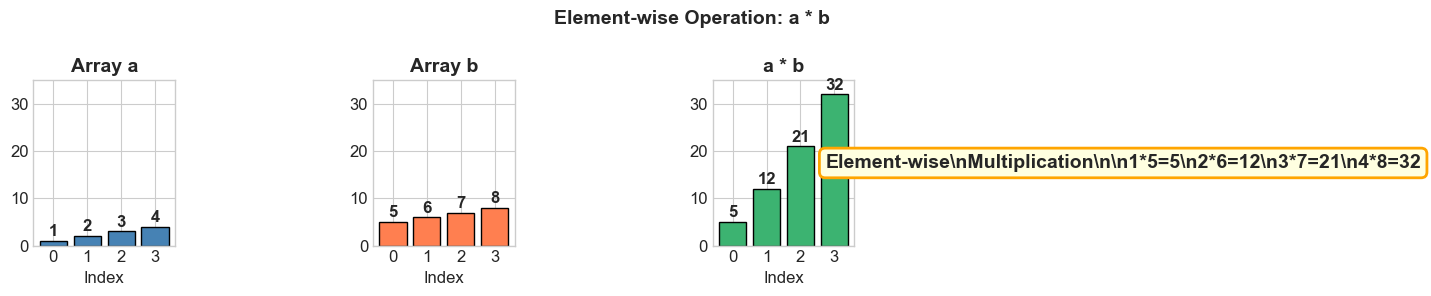

In [27]:
# Visualize element-wise multiplication
fig, axes = plt.subplots(1, 4, figsize=(14, 3))

a = np.array([1, 2, 3, 4])
b = np.array([5, 6, 7, 8])
result = a * b

colors = ['steelblue', 'coral', 'mediumseagreen']
labels = ['Array a', 'Array b', 'a * b']
data_arrays = [a, b, result]

for idx, (ax, arr, color, label) in enumerate(zip(axes[:3], data_arrays, colors, labels)):
    ax.bar(range(len(arr)), arr, color=color, edgecolor='black')
    ax.set_title(label, fontsize=14, fontweight='bold')
    ax.set_ylim(0, 35)
    for i, v in enumerate(arr):
        ax.text(i, v + 1, str(v), ha='center', fontweight='bold')
    ax.set_xticks(range(4))
    ax.set_xlabel('Index')

# Show the operation
axes[3].axis('off')
axes[3].text(0.5, 0.5, 'Element-wise\\nMultiplication\\n\\n1*5=5\\n2*6=12\\n3*7=21\\n4*8=32',
             ha='center', va='center', fontsize=14, fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='lightyellow', edgecolor='orange', linewidth=2))

plt.suptitle('Element-wise Operation: a * b', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3.2 Mathematical Functions

NumPy provides many mathematical functions that operate element-wise - these are the building blocks of activation functions!

In [28]:
# Essential math functions for deep learning
x = np.array([-2, -1, 0, 1, 2])
print("x =", x)
print()

# Exponential and logarithm
print(f"np.exp(x)  = {np.exp(x)}")
print("  -> Used in: Softmax, Sigmoid")
print()

print(f"np.log(np.abs(x) + 1) = {np.log(np.abs(x) + 1)}")
print("  -> Used in: Cross-entropy loss")
print()

# Trigonometric (for positional encoding in Transformers!)
print(f"np.sin(x) = {np.sin(x)}")
print(f"np.cos(x) = {np.cos(x)}")
print("  -> Used in: Positional encoding (Transformers)")

x = [-2 -1  0  1  2]

np.exp(x)  = [0.13533528 0.36787944 1.         2.71828183 7.3890561 ]
  -> Used in: Softmax, Sigmoid

np.log(np.abs(x) + 1) = [1.09861229 0.69314718 0.         0.69314718 1.09861229]
  -> Used in: Cross-entropy loss

np.sin(x) = [-0.90929743 -0.84147098  0.          0.84147098  0.90929743]
np.cos(x) = [-0.41614684  0.54030231  1.          0.54030231 -0.41614684]
  -> Used in: Positional encoding (Transformers)


### Deep Learning Connection: Activation Functions

Activation functions are just element-wise operations! Let's implement the most common ones:

In [29]:
# Implementing activation functions with NumPy!

def sigmoid(x):
    """Squashes values to (0, 1) - used for binary classification"""
    return 1 / (1 + np.exp(-x))

def tanh(x):
    """Squashes values to (-1, 1) - zero-centered"""
    return np.tanh(x)

def relu(x):
    """max(0, x) - most popular activation for hidden layers"""
    return np.maximum(0, x)

def leaky_relu(x, alpha=0.01):
    """Allows small negative gradients"""
    return np.where(x > 0, x, alpha * x)

def softmax(x):
    """Converts to probability distribution - used for classification"""
    exp_x = np.exp(x - np.max(x))  # Subtract max for numerical stability
    return exp_x / np.sum(exp_x)

# Test them
x = np.array([-2, -1, 0, 1, 2])
print("Input x:", x)
print()
print(f"sigmoid(x):    {sigmoid(x)}")
print(f"tanh(x):       {tanh(x)}")
print(f"relu(x):       {relu(x)}")
print(f"leaky_relu(x): {leaky_relu(x)}")
print(f"softmax(x):    {softmax(x)}  (sums to {softmax(x).sum():.2f})")

Input x: [-2 -1  0  1  2]

sigmoid(x):    [0.11920292 0.26894142 0.5        0.73105858 0.88079708]
tanh(x):       [-0.96402758 -0.76159416  0.          0.76159416  0.96402758]
relu(x):       [0 0 0 1 2]
leaky_relu(x): [-0.02 -0.01  0.    1.    2.  ]
softmax(x):    [0.01165623 0.03168492 0.08612854 0.23412166 0.63640865]  (sums to 1.00)


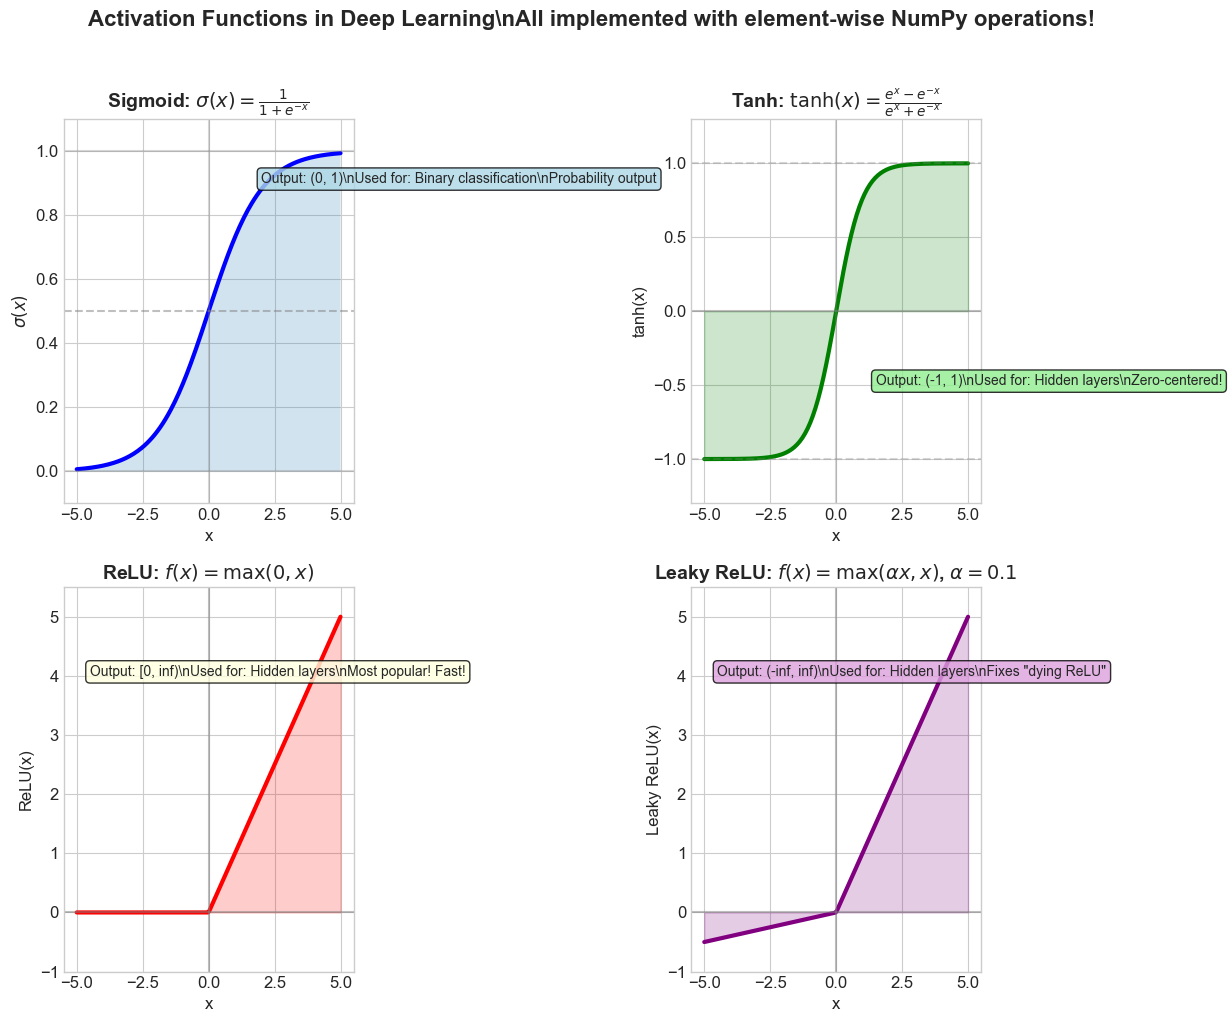

In [30]:
# Beautiful visualization of activation functions
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

x = np.linspace(-5, 5, 200)

# Sigmoid
ax = axes[0, 0]
ax.plot(x, sigmoid(x), 'b-', linewidth=3, label='Sigmoid')
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
ax.axhline(y=1, color='gray', linestyle='-', alpha=0.3)
ax.axvline(x=0, color='gray', linestyle='-', alpha=0.3)
ax.fill_between(x, 0, sigmoid(x), alpha=0.2)
ax.set_title('Sigmoid: $\\sigma(x) = \\frac{1}{1 + e^{-x}}$', fontsize=14, fontweight='bold')
ax.set_xlabel('x')
ax.set_ylabel('$\\sigma(x)$')
ax.set_ylim(-0.1, 1.1)
ax.annotate('Output: (0, 1)\\nUsed for: Binary classification\\nProbability output',
            xy=(2, 0.9), fontsize=10,
            bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

# Tanh
ax = axes[0, 1]
ax.plot(x, tanh(x), 'g-', linewidth=3, label='Tanh')
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.5)
ax.axhline(y=-1, color='gray', linestyle='--', alpha=0.3)
ax.axhline(y=1, color='gray', linestyle='--', alpha=0.3)
ax.axvline(x=0, color='gray', linestyle='-', alpha=0.3)
ax.fill_between(x, 0, tanh(x), alpha=0.2, color='green')
ax.set_title('Tanh: $\\tanh(x) = \\frac{e^x - e^{-x}}{e^x + e^{-x}}$', fontsize=14, fontweight='bold')
ax.set_xlabel('x')
ax.set_ylabel('tanh(x)')
ax.set_ylim(-1.3, 1.3)
ax.annotate('Output: (-1, 1)\\nUsed for: Hidden layers\\nZero-centered!',
            xy=(1.5, -0.5), fontsize=10,
            bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))

# ReLU
ax = axes[1, 0]
ax.plot(x, relu(x), 'r-', linewidth=3, label='ReLU')
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.5)
ax.axvline(x=0, color='gray', linestyle='-', alpha=0.5)
ax.fill_between(x[x >= 0], 0, relu(x[x >= 0]), alpha=0.2, color='red')
ax.set_title('ReLU: $f(x) = \\max(0, x)$', fontsize=14, fontweight='bold')
ax.set_xlabel('x')
ax.set_ylabel('ReLU(x)')
ax.set_ylim(-1, 5.5)
ax.annotate('Output: [0, inf)\\nUsed for: Hidden layers\\nMost popular! Fast!',
            xy=(-4.5, 4), fontsize=10,
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# Leaky ReLU
ax = axes[1, 1]
ax.plot(x, leaky_relu(x, 0.1), 'purple', linewidth=3, label='Leaky ReLU')
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.5)
ax.axvline(x=0, color='gray', linestyle='-', alpha=0.5)
ax.fill_between(x, 0, leaky_relu(x, 0.1), alpha=0.2, color='purple')
ax.set_title('Leaky ReLU: $f(x) = \\max(\\alpha x, x)$, $\\alpha=0.1$', fontsize=14, fontweight='bold')
ax.set_xlabel('x')
ax.set_ylabel('Leaky ReLU(x)')
ax.set_ylim(-1, 5.5)
ax.annotate('Output: (-inf, inf)\\nUsed for: Hidden layers\\nFixes "dying ReLU"',
            xy=(-4.5, 4), fontsize=10,
            bbox=dict(boxstyle='round', facecolor='plum', alpha=0.8))

plt.suptitle('Activation Functions in Deep Learning\\nAll implemented with element-wise NumPy operations!',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---

# Section 4: Broadcasting

## The Magic That Makes Neural Networks Work

**Broadcasting** allows NumPy to perform operations on arrays of different shapes. This is essential for:
- Adding biases to layer outputs (adding a vector to a matrix)
- Normalizing data (subtracting mean, dividing by std)
- Applying operations across batches

Without broadcasting, we'd need lots of explicit loops!

## 4.1 Broadcasting Basics

### The Rules
1. Arrays are compared from **right to left**
2. Dimensions are compatible if they're **equal** OR one of them is **1**
3. If an array has fewer dimensions, it's padded with 1s on the **left**

In [31]:
# Scalar + Array (simplest broadcasting)
arr = np.array([1, 2, 3, 4, 5])
scalar = 10

result = arr + scalar  # 10 is "broadcast" to [10, 10, 10, 10, 10]
print("Array + Scalar:")
print(f"  {arr}")
print(f"+ {scalar}")
print(f"= {result}")
print()
print("What happened: scalar 10 was 'stretched' to match the array shape!")

Array + Scalar:
  [1 2 3 4 5]
+ 10
= [11 12 13 14 15]

What happened: scalar 10 was 'stretched' to match the array shape!


In [32]:
# Matrix + Vector (most common in deep learning!)
matrix = np.array([[1, 2, 3],
                   [4, 5, 6],
                   [7, 8, 9]])
row_vector = np.array([10, 20, 30])

print("Matrix (3x3):")
print(matrix)
print(f"Shape: {matrix.shape}")
print()
print("Row vector:", row_vector)
print(f"Shape: {row_vector.shape}")
print()

result = matrix + row_vector
print("Matrix + Row Vector:")
print(result)
print()
print("The vector was broadcast across all rows!")

Matrix (3x3):
[[1 2 3]
 [4 5 6]
 [7 8 9]]
Shape: (3, 3)

Row vector: [10 20 30]
Shape: (3,)

Matrix + Row Vector:
[[11 22 33]
 [14 25 36]
 [17 28 39]]

The vector was broadcast across all rows!


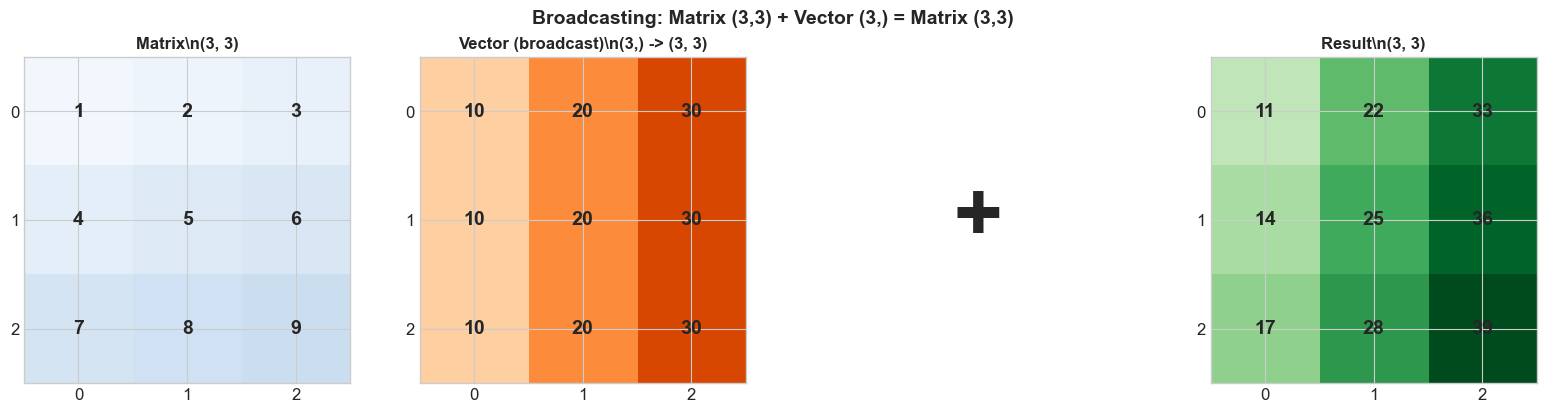

In [33]:
# Visualize broadcasting
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

matrix = np.array([[1, 2, 3],
                   [4, 5, 6],
                   [7, 8, 9]])
vector = np.array([10, 20, 30])
result = matrix + vector

# Original matrix
ax = axes[0]
im = ax.imshow(matrix, cmap='Blues', vmin=0, vmax=40)
ax.set_title('Matrix\\n(3, 3)', fontsize=12, fontweight='bold')
for i in range(3):
    for j in range(3):
        ax.text(j, i, matrix[i, j], ha='center', va='center', fontsize=14, fontweight='bold')
ax.set_xticks(range(3))
ax.set_yticks(range(3))

# Vector (shown as it will be broadcast)
ax = axes[1]
broadcast_viz = np.tile(vector, (3, 1))
im = ax.imshow(broadcast_viz, cmap='Oranges', vmin=0, vmax=40)
ax.set_title('Vector (broadcast)\\n(3,) -> (3, 3)', fontsize=12, fontweight='bold')
for i in range(3):
    for j in range(3):
        ax.text(j, i, broadcast_viz[i, j], ha='center', va='center', fontsize=14, fontweight='bold')
ax.set_xticks(range(3))
ax.set_yticks(range(3))

# Plus sign
ax = axes[2]
ax.axis('off')
ax.text(0.5, 0.5, '+', fontsize=60, ha='center', va='center', fontweight='bold')

# Result
ax = axes[3]
im = ax.imshow(result, cmap='Greens', vmin=0, vmax=40)
ax.set_title('Result\\n(3, 3)', fontsize=12, fontweight='bold')
for i in range(3):
    for j in range(3):
        ax.text(j, i, result[i, j], ha='center', va='center', fontsize=14, fontweight='bold')
ax.set_xticks(range(3))
ax.set_yticks(range(3))

plt.suptitle('Broadcasting: Matrix (3,3) + Vector (3,) = Matrix (3,3)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Deep Learning Connection: Bias Addition in Neural Networks

In a neural network layer, the forward pass is: **z = Wx + b**

Here, `b` is a bias vector that gets broadcast across all samples in a batch!

In [34]:
# Simulating a neural network layer with bias addition
print("Neural Network Layer: z = Wx + b")
print("=" * 50)

# Batch of 4 samples, each with 3 features
batch_size = 4
input_features = 3
output_features = 2

X = np.random.randn(batch_size, input_features)  # (4, 3)
W = np.random.randn(input_features, output_features)  # (3, 2)
b = np.array([0.5, -0.5])  # (2,) - one bias per output neuron

print(f"Input X shape: {X.shape}     <- (batch_size, input_features)")
print(f"Weights W shape: {W.shape}   <- (input_features, output_features)")
print(f"Bias b shape: {b.shape}         <- (output_features,)")
print()

# Forward pass
z = X @ W  # Matrix multiplication: (4, 3) @ (3, 2) = (4, 2)
print(f"X @ W shape: {z.shape}        <- (batch_size, output_features)")

# Add bias using broadcasting!
z = z + b  # Broadcasting: (4, 2) + (2,) = (4, 2)
print(f"z + b shape: {z.shape}        <- Same! Bias was broadcast across batch")
print()
print("Result (z = Wx + b):")
print(z)

Neural Network Layer: z = Wx + b
Input X shape: (4, 3)     <- (batch_size, input_features)
Weights W shape: (3, 2)   <- (input_features, output_features)
Bias b shape: (2,)         <- (output_features,)

X @ W shape: (4, 2)        <- (batch_size, output_features)
z + b shape: (4, 2)        <- Same! Bias was broadcast across batch

Result (z = Wx + b):
[[ 0.35262886 -0.14868992]
 [ 1.01725398 -0.95551432]
 [ 1.6505743  -0.97061206]
 [ 0.93434527 -1.67009057]]


---

# Section 5: Matrix Multiplication

## The Heart of Neural Networks

**Matrix multiplication (matmul)** is the most important operation in deep learning!

Every layer in a neural network performs: **output = input @ weights**

This is NOT element-wise multiplication - it's a specific mathematical operation that combines entire rows with entire columns.

## 5.1 Understanding Matrix Multiplication

For matrices A (m x n) and B (n x p):
- A @ B produces a matrix of shape (m x p)
- The **inner dimensions must match** (n = n)
- Each element is the **dot product** of a row from A and a column from B

In [35]:
# Matrix multiplication basics
A = np.array([[1, 2, 3],
              [4, 5, 6]])  # Shape: (2, 3)

B = np.array([[7, 8],
              [9, 10],
              [11, 12]])  # Shape: (3, 2)

print("Matrix A (2x3):")
print(A)
print()
print("Matrix B (3x2):")
print(B)
print()

# Matrix multiplication
C = A @ B  # or np.matmul(A, B) or np.dot(A, B)
print("C = A @ B (2x2):")
print(C)
print()
print(f"Shape: {A.shape} @ {B.shape} = {C.shape}")
print("  (2, 3) @ (3, 2) -> inner dims match (3=3) -> output (2, 2)")

Matrix A (2x3):
[[1 2 3]
 [4 5 6]]

Matrix B (3x2):
[[ 7  8]
 [ 9 10]
 [11 12]]

C = A @ B (2x2):
[[ 58  64]
 [139 154]]

Shape: (2, 3) @ (3, 2) = (2, 2)
  (2, 3) @ (3, 2) -> inner dims match (3=3) -> output (2, 2)


In [36]:
# Let's break down exactly what happens
print("How Matrix Multiplication Works:")
print("=" * 50)

A = np.array([[1, 2, 3],
              [4, 5, 6]])

B = np.array([[7, 8],
              [9, 10],
              [11, 12]])

print("A @ B element by element:")
print()

# Calculate each element
for i in range(2):
    for j in range(2):
        row = A[i, :]
        col = B[:, j]
        dot = np.dot(row, col)

        calc = " + ".join([f"{r}*{c}" for r, c in zip(row, col)])
        print(f"C[{i},{j}] = Row {i} of A . Col {j} of B")
        print(f"       = {row} . {col}")
        print(f"       = {calc}")
        print(f"       = {dot}")
        print()

How Matrix Multiplication Works:
A @ B element by element:

C[0,0] = Row 0 of A . Col 0 of B
       = [1 2 3] . [ 7  9 11]
       = 1*7 + 2*9 + 3*11
       = 58

C[0,1] = Row 0 of A . Col 1 of B
       = [1 2 3] . [ 8 10 12]
       = 1*8 + 2*10 + 3*12
       = 64

C[1,0] = Row 1 of A . Col 0 of B
       = [4 5 6] . [ 7  9 11]
       = 4*7 + 5*9 + 6*11
       = 139

C[1,1] = Row 1 of A . Col 1 of B
       = [4 5 6] . [ 8 10 12]
       = 4*8 + 5*10 + 6*12
       = 154



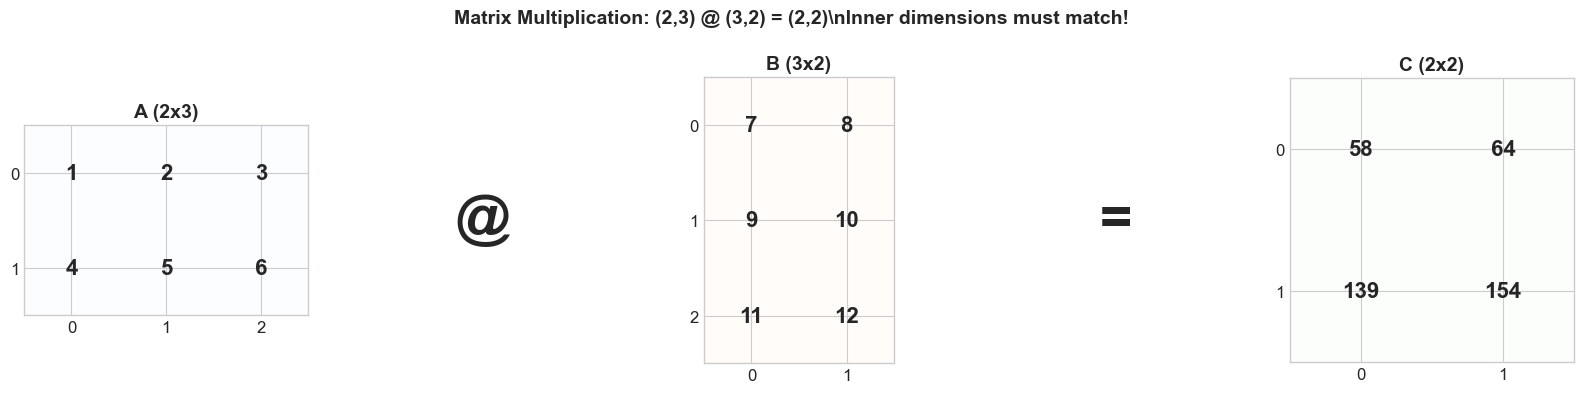

In [37]:
# Visual representation of matrix multiplication
fig, axes = plt.subplots(1, 5, figsize=(16, 4))

A = np.array([[1, 2, 3],
              [4, 5, 6]])
B = np.array([[7, 8],
              [9, 10],
              [11, 12]])
C = A @ B

# Matrix A
ax = axes[0]
ax.imshow(np.ones_like(A), cmap='Blues', alpha=0.3)
for i in range(2):
    for j in range(3):
        ax.text(j, i, str(A[i, j]), ha='center', va='center', fontsize=16, fontweight='bold')
ax.set_title('A (2x3)', fontsize=14, fontweight='bold')
ax.set_xticks(range(3))
ax.set_yticks(range(2))
ax.set_aspect('equal')

# @ symbol
ax = axes[1]
ax.axis('off')
ax.text(0.5, 0.5, '@', fontsize=40, ha='center', va='center', fontweight='bold')

# Matrix B
ax = axes[2]
ax.imshow(np.ones_like(B), cmap='Oranges', alpha=0.3)
for i in range(3):
    for j in range(2):
        ax.text(j, i, str(B[i, j]), ha='center', va='center', fontsize=16, fontweight='bold')
ax.set_title('B (3x2)', fontsize=14, fontweight='bold')
ax.set_xticks(range(2))
ax.set_yticks(range(3))
ax.set_aspect('equal')

# = symbol
ax = axes[3]
ax.axis('off')
ax.text(0.5, 0.5, '=', fontsize=40, ha='center', va='center', fontweight='bold')

# Result C
ax = axes[4]
ax.imshow(np.ones_like(C), cmap='Greens', alpha=0.3)
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(C[i, j]), ha='center', va='center', fontsize=16, fontweight='bold')
ax.set_title('C (2x2)', fontsize=14, fontweight='bold')
ax.set_xticks(range(2))
ax.set_yticks(range(2))
ax.set_aspect('equal')

plt.suptitle('Matrix Multiplication: (2,3) @ (3,2) = (2,2)\\nInner dimensions must match!',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Deep Learning Connection: The Forward Pass

A neural network layer is essentially: **output = activation(input @ weights + bias)**

Let's see this in action with a complete example!

In [38]:
# Complete forward pass through a neural network layer
print("Forward Pass Through a Dense Layer")
print("=" * 50)

# A batch of 3 samples, each with 4 features
X = np.array([[0.1, 0.2, 0.3, 0.4],
              [0.5, 0.6, 0.7, 0.8],
              [0.9, 1.0, 1.1, 1.2]])

# Weight matrix: 4 inputs -> 3 outputs
W = np.array([[0.1, 0.2, 0.3],
              [0.4, 0.5, 0.6],
              [0.7, 0.8, 0.9],
              [1.0, 1.1, 1.2]])

# Bias: one per output
b = np.array([0.1, 0.2, 0.3])

print(f"Input X shape: {X.shape}  (batch_size=3, input_features=4)")
print(f"Weights W shape: {W.shape}  (input_features=4, output_features=3)")
print(f"Bias b shape: {b.shape}  (output_features=3)")
print()

# Step 1: Linear transformation (matrix multiplication)
z = X @ W
print(f"Step 1 - Linear: z = X @ W")
print(f"  z shape: {z.shape}")
print(f"  z = \\n{z}")
print()

# Step 2: Add bias (broadcasting!)
z = z + b
print(f"Step 2 - Add bias: z = z + b (broadcasting!)")
print(f"  z = \\n{z}")
print()

# Step 3: Apply activation
a = sigmoid(z)  # Using our sigmoid from earlier
print(f"Step 3 - Activation: a = sigmoid(z)")
print(f"  a = \\n{a}")
print()

print("This output becomes the input to the next layer!")

Forward Pass Through a Dense Layer
Input X shape: (3, 4)  (batch_size=3, input_features=4)
Weights W shape: (4, 3)  (input_features=4, output_features=3)
Bias b shape: (3,)  (output_features=3)

Step 1 - Linear: z = X @ W
  z shape: (3, 3)
  z = \n[[0.7  0.8  0.9 ]
 [1.58 1.84 2.1 ]
 [2.46 2.88 3.3 ]]

Step 2 - Add bias: z = z + b (broadcasting!)
  z = \n[[0.8  1.   1.2 ]
 [1.68 2.04 2.4 ]
 [2.56 3.08 3.6 ]]

Step 3 - Activation: a = sigmoid(z)
  a = \n[[0.68997448 0.73105858 0.76852478]
 [0.84290453 0.88493327 0.9168273 ]
 [0.92824246 0.95606018 0.97340301]]

This output becomes the input to the next layer!


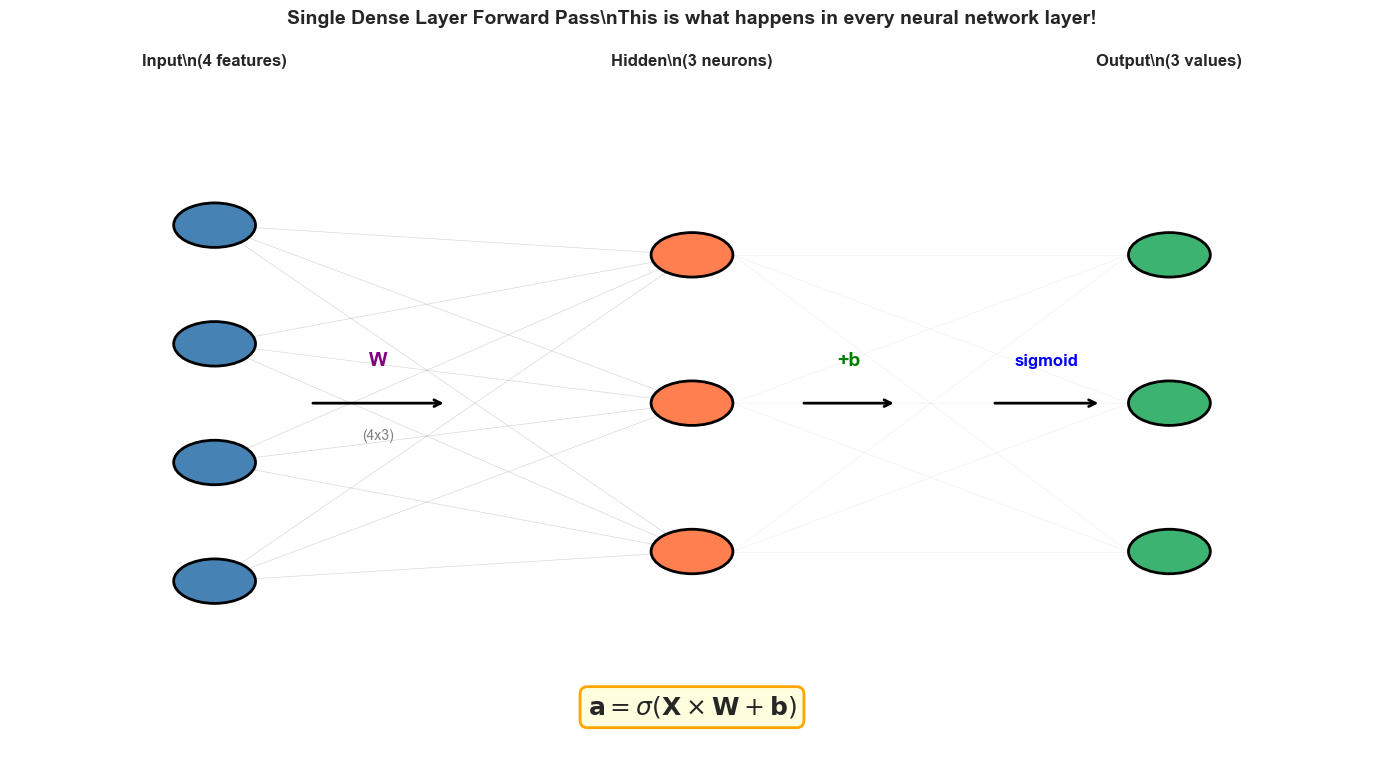

In [39]:
# Visualize neural network layer computation
fig, ax = plt.subplots(figsize=(14, 8))
ax.axis('off')

# Draw the network
def draw_layer(ax, x, num_neurons, label, color):
    positions = []
    spacing = 0.8 / (num_neurons + 1)
    for i in range(num_neurons):
        y = 0.9 - (i + 1) * spacing
        circle = plt.Circle((x, y), 0.03, color=color, ec='black', linewidth=2, zorder=3)
        ax.add_patch(circle)
        positions.append((x, y))
    ax.text(x, 0.95, label, ha='center', va='bottom', fontsize=12, fontweight='bold')
    return positions

# Input layer (4 neurons)
input_pos = draw_layer(ax, 0.15, 4, 'Input\\n(4 features)', 'steelblue')

# Hidden layer (3 neurons)
hidden_pos = draw_layer(ax, 0.5, 3, 'Hidden\\n(3 neurons)', 'coral')

# Draw connections (weights)
for inp in input_pos:
    for hid in hidden_pos:
        ax.plot([inp[0], hid[0]], [inp[1], hid[1]], 'gray', alpha=0.3, linewidth=0.5)

# Add operation labels
ax.annotate('', xy=(0.32, 0.5), xytext=(0.22, 0.5),
            arrowprops=dict(arrowstyle='->', color='black', lw=2))
ax.text(0.27, 0.55, 'W', ha='center', fontsize=14, fontweight='bold', color='purple')
ax.text(0.27, 0.45, '(4x3)', ha='center', fontsize=10, color='gray')

ax.annotate('', xy=(0.65, 0.5), xytext=(0.58, 0.5),
            arrowprops=dict(arrowstyle='->', color='black', lw=2))
ax.text(0.615, 0.55, '+b', ha='center', fontsize=14, fontweight='bold', color='green')

ax.annotate('', xy=(0.80, 0.5), xytext=(0.72, 0.5),
            arrowprops=dict(arrowstyle='->', color='black', lw=2))
ax.text(0.76, 0.55, 'sigmoid', ha='center', fontsize=12, fontweight='bold', color='blue')

# Output
output_pos = draw_layer(ax, 0.85, 3, 'Output\\n(3 values)', 'mediumseagreen')

# Draw connections from hidden to output (just for visualization)
for hid in hidden_pos:
    for out in output_pos:
        ax.plot([hid[0] + 0.03, out[0] - 0.03], [hid[1], out[1]], 'gray', alpha=0.1, linewidth=0.5)

# Add formula
ax.text(0.5, 0.08, r'$\mathbf{a} = \sigma(\mathbf{X} \times \mathbf{W} + \mathbf{b})$',
        ha='center', fontsize=18, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='lightyellow', edgecolor='orange', linewidth=2))

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_title('Single Dense Layer Forward Pass\\nThis is what happens in every neural network layer!',
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

---

# Section 6: Statistics and Aggregation

## Essential for Loss Functions and Normalization

Statistical operations are crucial for:
- **Loss functions**: Mean Squared Error, Cross-Entropy
- **Batch Normalization**: Mean and variance across batches
- **Data preprocessing**: Standardization, normalization
- **Model evaluation**: Accuracy, averages

In [40]:
# Basic aggregations
arr = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
print("Array:", arr)
print()

print(f"np.sum(arr)  = {np.sum(arr)}     <- Total")
print(f"np.mean(arr) = {np.mean(arr)}    <- Average")
print(f"np.std(arr)  = {np.std(arr):.4f}  <- Standard deviation")
print(f"np.var(arr)  = {np.var(arr):.4f}  <- Variance")
print(f"np.min(arr)  = {np.min(arr)}      <- Minimum")
print(f"np.max(arr)  = {np.max(arr)}     <- Maximum")
print(f"np.argmax(arr) = {np.argmax(arr)}   <- Index of maximum")

Array: [ 1  2  3  4  5  6  7  8  9 10]

np.sum(arr)  = 55     <- Total
np.mean(arr) = 5.5    <- Average
np.std(arr)  = 2.8723  <- Standard deviation
np.var(arr)  = 8.2500  <- Variance
np.min(arr)  = 1      <- Minimum
np.max(arr)  = 10     <- Maximum
np.argmax(arr) = 9   <- Index of maximum


## 6.1 The `axis` Parameter - Critical for Deep Learning!

The `axis` parameter specifies which dimension to aggregate over. This is essential for batch operations!

In [41]:
# Understanding axis
matrix = np.array([[1, 2, 3],
                   [4, 5, 6],
                   [7, 8, 9]])

print("Matrix:")
print(matrix)
print(f"Shape: {matrix.shape}")
print()

print(f"np.sum(matrix)         = {np.sum(matrix)}    <- Sum all elements")
print(f"np.sum(matrix, axis=0) = {np.sum(matrix, axis=0)}  <- Sum along rows (collapse axis 0)")
print(f"np.sum(matrix, axis=1) = {np.sum(matrix, axis=1)}  <- Sum along columns (collapse axis 1)")

Matrix:
[[1 2 3]
 [4 5 6]
 [7 8 9]]
Shape: (3, 3)

np.sum(matrix)         = 45    <- Sum all elements
np.sum(matrix, axis=0) = [12 15 18]  <- Sum along rows (collapse axis 0)
np.sum(matrix, axis=1) = [ 6 15 24]  <- Sum along columns (collapse axis 1)


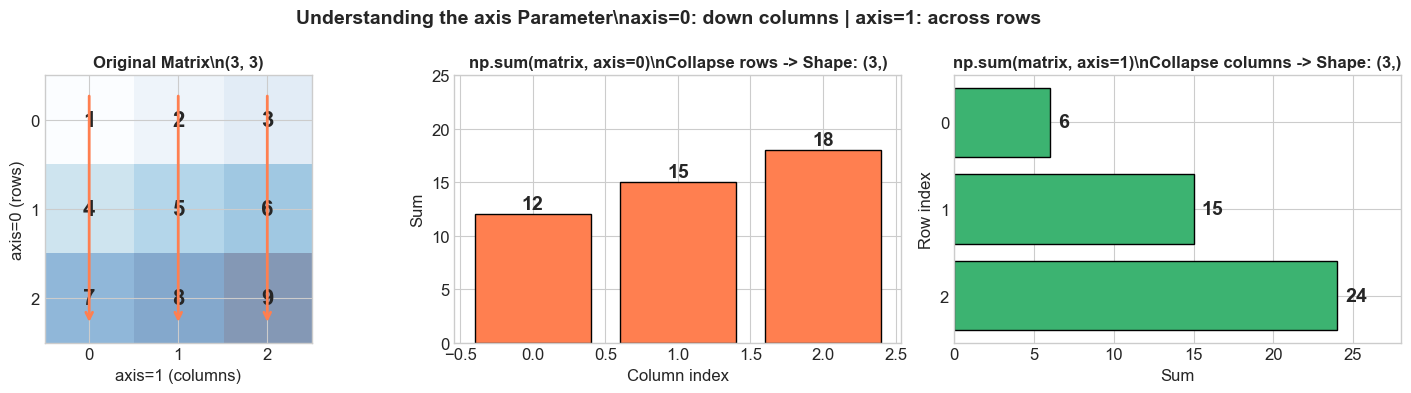

In [42]:
# Visualize axis operations
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

matrix = np.array([[1, 2, 3],
                   [4, 5, 6],
                   [7, 8, 9]])

# Original matrix
ax = axes[0]
ax.imshow(matrix, cmap='Blues', alpha=0.5)
for i in range(3):
    for j in range(3):
        ax.text(j, i, str(matrix[i, j]), ha='center', va='center', fontsize=16, fontweight='bold')
ax.set_title('Original Matrix\\n(3, 3)', fontsize=12, fontweight='bold')
ax.set_xticks(range(3))
ax.set_yticks(range(3))
ax.set_ylabel('axis=0 (rows)')
ax.set_xlabel('axis=1 (columns)')

# Sum along axis=0 (collapse rows)
ax = axes[1]
result = np.sum(matrix, axis=0)
ax.bar(range(3), result, color='coral', edgecolor='black')
for i, v in enumerate(result):
    ax.text(i, v + 0.5, str(v), ha='center', fontweight='bold', fontsize=14)
ax.set_title('np.sum(matrix, axis=0)\\nCollapse rows -> Shape: (3,)', fontsize=12, fontweight='bold')
ax.set_xlabel('Column index')
ax.set_ylabel('Sum')
ax.set_ylim(0, 25)

# Add arrows showing direction
for i in range(3):
    axes[0].annotate('', xy=(i, 2.3), xytext=(i, -0.3),
                     arrowprops=dict(arrowstyle='->', color='coral', lw=2))

# Sum along axis=1 (collapse columns)
ax = axes[2]
result = np.sum(matrix, axis=1)
ax.barh(range(3), result, color='mediumseagreen', edgecolor='black')
for i, v in enumerate(result):
    ax.text(v + 0.5, i, str(v), va='center', fontweight='bold', fontsize=14)
ax.set_title('np.sum(matrix, axis=1)\\nCollapse columns -> Shape: (3,)', fontsize=12, fontweight='bold')
ax.set_ylabel('Row index')
ax.set_xlabel('Sum')
ax.set_xlim(0, 28)
ax.set_yticks(range(3))
ax.invert_yaxis()

plt.suptitle('Understanding the axis Parameter\\naxis=0: down columns | axis=1: across rows',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Deep Learning Connection: Loss Functions

In [43]:
# Implementing loss functions with NumPy aggregations

def mean_squared_error(y_true, y_pred):
    """MSE = mean((y_true - y_pred)^2)"""
    return np.mean((y_true - y_pred) ** 2)

def binary_cross_entropy(y_true, y_pred, epsilon=1e-15):
    """BCE = -mean(y*log(p) + (1-y)*log(1-p))"""
    # Clip predictions to prevent log(0)
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

# Test MSE
y_true = np.array([1.0, 2.0, 3.0, 4.0, 5.0])
y_pred = np.array([1.1, 2.2, 2.8, 4.1, 4.9])

print("Mean Squared Error (MSE)")
print("=" * 40)
print(f"y_true: {y_true}")
print(f"y_pred: {y_pred}")
print(f"errors: {y_true - y_pred}")
print(f"squared errors: {(y_true - y_pred) ** 2}")
print(f"MSE = {mean_squared_error(y_true, y_pred):.4f}")
print()

# Test BCE
y_true_binary = np.array([1, 0, 1, 1, 0])
y_pred_probs = np.array([0.9, 0.1, 0.8, 0.7, 0.2])

print("Binary Cross-Entropy (BCE)")
print("=" * 40)
print(f"y_true: {y_true_binary}")
print(f"y_pred: {y_pred_probs}")
print(f"BCE = {binary_cross_entropy(y_true_binary, y_pred_probs):.4f}")

Mean Squared Error (MSE)
y_true: [1. 2. 3. 4. 5.]
y_pred: [1.1 2.2 2.8 4.1 4.9]
errors: [-0.1 -0.2  0.2 -0.1  0.1]
squared errors: [0.01 0.04 0.04 0.01 0.01]
MSE = 0.0220

Binary Cross-Entropy (BCE)
y_true: [1 0 1 1 0]
y_pred: [0.9 0.1 0.8 0.7 0.2]
BCE = 0.2027


---

# Section 7: Reshaping and Manipulation

## Transforming Tensor Shapes

Reshaping is essential for:
- **Flattening images** for fully connected layers
- **Preparing data** for different layer types (Conv vs Dense)
- **Batch processing** - adding/removing dimensions
- **Transpose** for matrix multiplication alignment

In [44]:
# reshape() - change shape while keeping all elements
arr = np.arange(12)
print("Original 1D array:", arr)
print(f"Shape: {arr.shape}")
print()

# Reshape to 2D
reshaped_2d = arr.reshape(3, 4)  # 3 rows, 4 columns
print("Reshaped to (3, 4):")
print(reshaped_2d)
print()

# Reshape to 3D
reshaped_3d = arr.reshape(2, 2, 3)  # 2 batches, 2 rows, 3 columns
print("Reshaped to (2, 2, 3):")
print(reshaped_3d)
print()

# Use -1 to auto-calculate one dimension
auto_reshaped = arr.reshape(3, -1)  # -1 means "figure it out"
print("Reshaped with -1: arr.reshape(3, -1)")
print(auto_reshaped)
print(f"Shape: {auto_reshaped.shape}  <- NumPy calculated 4 columns")

Original 1D array: [ 0  1  2  3  4  5  6  7  8  9 10 11]
Shape: (12,)

Reshaped to (3, 4):
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]

Reshaped to (2, 2, 3):
[[[ 0  1  2]
  [ 3  4  5]]

 [[ 6  7  8]
  [ 9 10 11]]]

Reshaped with -1: arr.reshape(3, -1)
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
Shape: (3, 4)  <- NumPy calculated 4 columns


In [45]:
# Deep Learning Use Case: Flattening images for Dense layers
print("Flattening Images for Neural Networks")
print("=" * 50)

# A batch of 4 MNIST images (28x28 grayscale)
batch_images = np.random.rand(4, 28, 28)
print(f"Original batch shape: {batch_images.shape}")
print("  -> (batch_size, height, width)")
print()

# Flatten for a Dense layer: keep batch dimension, flatten rest
flattened = batch_images.reshape(4, -1)  # -1 = 28*28 = 784
print(f"Flattened shape: {flattened.shape}")
print("  -> (batch_size, features)")
print()

# Alternative: use .flatten() or .ravel() for single images
single_image = batch_images[0]  # Shape: (28, 28)
flat_image = single_image.flatten()  # Shape: (784,)
print(f"Single image: {single_image.shape} -> flattened: {flat_image.shape}")

Flattening Images for Neural Networks
Original batch shape: (4, 28, 28)
  -> (batch_size, height, width)

Flattened shape: (4, 784)
  -> (batch_size, features)

Single image: (28, 28) -> flattened: (784,)


In [46]:
# Transpose - swap axes
matrix = np.array([[1, 2, 3],
                   [4, 5, 6]])

print("Original (2x3):")
print(matrix)
print()

print("Transposed (3x2):")
print(matrix.T)  # or np.transpose(matrix)
print()

# Deep Learning Use: Aligning matrices for multiplication
print("Deep Learning Use: Transposing for matrix multiplication")
X = np.random.rand(32, 10)  # 32 samples, 10 features
print(f"X shape: {X.shape}")
print(f"X.T shape: {X.T.shape}")
print(f"X.T @ X shape: {(X.T @ X).shape}  <- Covariance-like operation")

Original (2x3):
[[1 2 3]
 [4 5 6]]

Transposed (3x2):
[[1 4]
 [2 5]
 [3 6]]

Deep Learning Use: Transposing for matrix multiplication
X shape: (32, 10)
X.T shape: (10, 32)
X.T @ X shape: (10, 10)  <- Covariance-like operation


/var/folders/mz/9z30xzjs3sd9h00px0g18mqr0000gn/T/ipykernel_97833/2708791950.py:18: RuntimeWarning: divide by zero encountered in matmul
  print(f"X.T @ X shape: {(X.T @ X).shape}  <- Covariance-like operation")
/var/folders/mz/9z30xzjs3sd9h00px0g18mqr0000gn/T/ipykernel_97833/2708791950.py:18: RuntimeWarning: overflow encountered in matmul
  print(f"X.T @ X shape: {(X.T @ X).shape}  <- Covariance-like operation")
/var/folders/mz/9z30xzjs3sd9h00px0g18mqr0000gn/T/ipykernel_97833/2708791950.py:18: RuntimeWarning: invalid value encountered in matmul
  print(f"X.T @ X shape: {(X.T @ X).shape}  <- Covariance-like operation")


---

# Section 8: Random Number Generation

## The Foundation of Weight Initialization

Random numbers are essential for:
- **Weight initialization** - starting neural network training
- **Dropout** - randomly zeroing neurons during training
- **Data augmentation** - random transformations
- **Shuffling data** - randomizing batch order

In [47]:
# Random number generation basics
np.random.seed(42)  # For reproducibility - IMPORTANT in research!

# Uniform distribution [0, 1)
uniform = np.random.rand(3, 4)
print("Uniform [0, 1) - np.random.rand(3, 4):")
print(uniform)
print()

# Standard normal (Gaussian) - mean=0, std=1
normal = np.random.randn(3, 4)
print("Standard Normal - np.random.randn(3, 4):")
print(normal)
print()

# Random integers
integers = np.random.randint(0, 10, size=(3, 4))  # [low, high)
print("Random integers [0, 10) - np.random.randint(0, 10, (3, 4)):")
print(integers)

Uniform [0, 1) - np.random.rand(3, 4):
[[0.37454012 0.95071431 0.73199394 0.59865848]
 [0.15601864 0.15599452 0.05808361 0.86617615]
 [0.60111501 0.70807258 0.02058449 0.96990985]]

Standard Normal - np.random.randn(3, 4):
[[-0.46947439  0.54256004 -0.46341769 -0.46572975]
 [ 0.24196227 -1.91328024 -1.72491783 -0.56228753]
 [-1.01283112  0.31424733 -0.90802408 -1.4123037 ]]

Random integers [0, 10) - np.random.randint(0, 10, (3, 4)):
[[2 6 3 8]
 [2 4 2 6]
 [4 8 6 1]]


### Deep Learning Connection: Weight Initialization

How you initialize weights **dramatically affects training**! Let's implement the most important schemes:

In [48]:
# Weight initialization schemes
def xavier_init(n_in, n_out):
    """Xavier/Glorot initialization - good for tanh/sigmoid"""
    std = np.sqrt(2.0 / (n_in + n_out))
    return np.random.randn(n_in, n_out) * std

def he_init(n_in, n_out):
    """He initialization - best for ReLU"""
    std = np.sqrt(2.0 / n_in)
    return np.random.randn(n_in, n_out) * std

def lecun_init(n_in, n_out):
    """LeCun initialization - good for SELU"""
    std = np.sqrt(1.0 / n_in)
    return np.random.randn(n_in, n_out) * std

# Compare initializations for a layer: 784 inputs -> 256 outputs
n_in, n_out = 784, 256

np.random.seed(42)
random_weights = np.random.randn(n_in, n_out)  # No scaling - BAD!
xavier_weights = xavier_init(n_in, n_out)
he_weights = he_init(n_in, n_out)

print("Weight Statistics Comparison (784 -> 256 layer):")
print("=" * 60)
print(f"{'Method':<15} {'Mean':>10} {'Std':>10} {'Min':>10} {'Max':>10}")
print("-" * 60)
print(f"{'Random':<15} {random_weights.mean():>10.4f} {random_weights.std():>10.4f} {random_weights.min():>10.4f} {random_weights.max():>10.4f}")
print(f"{'Xavier':<15} {xavier_weights.mean():>10.4f} {xavier_weights.std():>10.4f} {xavier_weights.min():>10.4f} {xavier_weights.max():>10.4f}")
print(f"{'He':<15} {he_weights.mean():>10.4f} {he_weights.std():>10.4f} {he_weights.min():>10.4f} {he_weights.max():>10.4f}")

Weight Statistics Comparison (784 -> 256 layer):
Method                Mean        Std        Min        Max
------------------------------------------------------------
Random              0.0011     0.9998    -4.4656     4.5621
Xavier             -0.0000     0.0439    -0.1936     0.1850
He                 -0.0002     0.0506    -0.2439     0.2363


---

# Section 9: Vectorization - Why NumPy is Fast

## The Key to Efficient Deep Learning

**Vectorization** means replacing explicit loops with array operations. This is:
- **10-100x faster** than Python loops
- **Essential** for training neural networks on large datasets
- **Automatic** when using NumPy/PyTorch/TensorFlow

In [49]:
import time

# Speed comparison: Loop vs Vectorized
n = 1_000_000

a = np.random.rand(n)
b = np.random.rand(n)

# Method 1: Python loop (SLOW)
start = time.time()
result_loop = []
for i in range(n):
    result_loop.append(a[i] + b[i])
loop_time = time.time() - start

# Method 2: NumPy vectorized (FAST)
start = time.time()
result_vectorized = a + b
vector_time = time.time() - start

print("Speed Comparison: Adding 1,000,000 element pairs")
print("=" * 50)
print(f"Python loop:  {loop_time:.4f} seconds")
print(f"NumPy vector: {vector_time:.6f} seconds")
print(f"Speedup:      {loop_time/vector_time:.1f}x faster!")
print()
print("This is why deep learning frameworks use vectorized operations!")

Speed Comparison: Adding 1,000,000 element pairs
Python loop:  0.0984 seconds
NumPy vector: 0.001091 seconds
Speedup:      90.2x faster!

This is why deep learning frameworks use vectorized operations!


---

# Section 10: Putting It All Together - A Mini Neural Network

## Everything You've Learned in Action!

Now let's combine ALL the NumPy concepts to build a working neural network that learns the XOR problem - a classic example that requires hidden layers!

In [50]:
# The XOR Problem - impossible for single-layer networks!
print("The XOR Problem")
print("=" * 40)
print("Input A | Input B | XOR Output")
print("-" * 40)
print("   0    |    0    |     0     ")
print("   0    |    1    |     1     ")
print("   1    |    0    |     1     ")
print("   1    |    1    |     0     ")
print()
print("This pattern CANNOT be learned without hidden layers!")
print("A neural network must learn this non-linear relationship.")

The XOR Problem
Input A | Input B | XOR Output
----------------------------------------
   0    |    0    |     0     
   0    |    1    |     1     
   1    |    0    |     1     
   1    |    1    |     0     

This pattern CANNOT be learned without hidden layers!
A neural network must learn this non-linear relationship.


In [51]:
class MiniNeuralNetwork:
    """
    A simple 2-layer neural network using only NumPy!

    This demonstrates:
    - Arrays: Weight matrices and biases
    - Indexing: Batch processing
    - Element-wise ops: Activations
    - Broadcasting: Bias addition
    - Matrix multiplication: Forward pass
    - Statistics: Loss computation
    - Random: Weight initialization
    """

    def __init__(self, input_size, hidden_size, output_size):
        # He initialization (Section 8)
        self.W1 = np.random.randn(input_size, hidden_size) * np.sqrt(2.0 / input_size)
        self.b1 = np.zeros(hidden_size)  # Bias init to zero

        self.W2 = np.random.randn(hidden_size, output_size) * np.sqrt(2.0 / hidden_size)
        self.b2 = np.zeros(output_size)

    def sigmoid(self, x):
        # Element-wise operation (Section 3)
        return 1 / (1 + np.exp(-np.clip(x, -500, 500)))

    def sigmoid_derivative(self, x):
        # For backpropagation
        return x * (1 - x)

    def forward(self, X):
        # Layer 1: Matrix multiplication + broadcasting + activation (Sections 4, 5)
        self.z1 = X @ self.W1 + self.b1  # Broadcasting bias!
        self.a1 = self.sigmoid(self.z1)  # Element-wise activation

        # Layer 2
        self.z2 = self.a1 @ self.W2 + self.b2
        self.a2 = self.sigmoid(self.z2)

        return self.a2

    def backward(self, X, y, learning_rate=0.5):
        m = X.shape[0]  # Batch size

        # Output layer error
        delta2 = (self.a2 - y) * self.sigmoid_derivative(self.a2)

        # Hidden layer error
        delta1 = (delta2 @ self.W2.T) * self.sigmoid_derivative(self.a1)

        # Gradient descent updates
        self.W2 -= learning_rate * (self.a1.T @ delta2) / m
        self.b2 -= learning_rate * np.mean(delta2, axis=0)  # Mean across batch (Section 6)

        self.W1 -= learning_rate * (X.T @ delta1) / m
        self.b1 -= learning_rate * np.mean(delta1, axis=0)

    def train(self, X, y, epochs=10000, print_every=1000):
        losses = []
        for epoch in range(epochs):
            # Forward pass
            output = self.forward(X)

            # Compute loss (MSE - Section 6)
            loss = np.mean((y - output) ** 2)
            losses.append(loss)

            # Backward pass
            self.backward(X, y)

            if epoch % print_every == 0:
                print(f"Epoch {epoch:5d} | Loss: {loss:.6f}")

        return losses

    def predict(self, X):
        return self.forward(X)

In [52]:
# Train on XOR!
np.random.seed(42)

# XOR dataset (Section 1 - Arrays)
X = np.array([[0, 0],
              [0, 1],
              [1, 0],
              [1, 1]])

y = np.array([[0],
              [1],
              [1],
              [0]])

print("Training Neural Network on XOR Problem")
print("=" * 50)
print(f"Input shape: {X.shape}  (4 samples, 2 features)")
print(f"Output shape: {y.shape} (4 samples, 1 output)")
print()

# Create network: 2 inputs -> 4 hidden -> 1 output
nn = MiniNeuralNetwork(input_size=2, hidden_size=4, output_size=1)

# Train!
losses = nn.train(X, y, epochs=10001, print_every=2000)

Training Neural Network on XOR Problem
Input shape: (4, 2)  (4 samples, 2 features)
Output shape: (4, 1) (4 samples, 1 output)

Epoch     0 | Loss: 0.268272
Epoch  2000 | Loss: 0.183650
Epoch  4000 | Loss: 0.022198


Epoch  6000 | Loss: 0.005429
Epoch  8000 | Loss: 0.002847


Epoch 10000 | Loss: 0.001889


In [53]:
# Test the trained network
print("\\nResults After Training:")
print("=" * 50)
predictions = nn.predict(X)

print(f"{'Input':<15} {'Target':<10} {'Prediction':<12} {'Rounded':<10}")
print("-" * 50)
for i in range(len(X)):
    pred = predictions[i, 0]
    rounded = round(pred)
    correct = "" if rounded == y[i, 0] else "X"
    print(f"{str(X[i]):<15} {y[i, 0]:<10} {pred:<12.4f} {rounded:<10} {correct}")

accuracy = np.mean((np.round(predictions) == y).astype(float)) * 100
print(f"\\nAccuracy: {accuracy:.0f}%")

\nResults After Training:
Input           Target     Prediction   Rounded   
--------------------------------------------------
[0 0]           0          0.0440       0          
[0 1]           1          0.9543       1          
[1 0]           1          0.9621       1          
[1 1]           0          0.0458       0          
\nAccuracy: 100%


/var/folders/mz/9z30xzjs3sd9h00px0g18mqr0000gn/T/ipykernel_97833/4169256107.py:33: RuntimeWarning: divide by zero encountered in matmul
  self.z1 = X @ self.W1 + self.b1  # Broadcasting bias!
/var/folders/mz/9z30xzjs3sd9h00px0g18mqr0000gn/T/ipykernel_97833/4169256107.py:33: RuntimeWarning: overflow encountered in matmul
  self.z1 = X @ self.W1 + self.b1  # Broadcasting bias!
/var/folders/mz/9z30xzjs3sd9h00px0g18mqr0000gn/T/ipykernel_97833/4169256107.py:33: RuntimeWarning: invalid value encountered in matmul
  self.z1 = X @ self.W1 + self.b1  # Broadcasting bias!
/var/folders/mz/9z30xzjs3sd9h00px0g18mqr0000gn/T/ipykernel_97833/4169256107.py:37: RuntimeWarning: divide by zero encountered in matmul
  self.z2 = self.a1 @ self.W2 + self.b2
/var/folders/mz/9z30xzjs3sd9h00px0g18mqr0000gn/T/ipykernel_97833/4169256107.py:37: RuntimeWarning: overflow encountered in matmul
  self.z2 = self.a1 @ self.W2 + self.b2
/var/folders/mz/9z30xzjs3sd9h00px0g18mqr0000gn/T/ipykernel_97833/4169256107.py:37: Ru

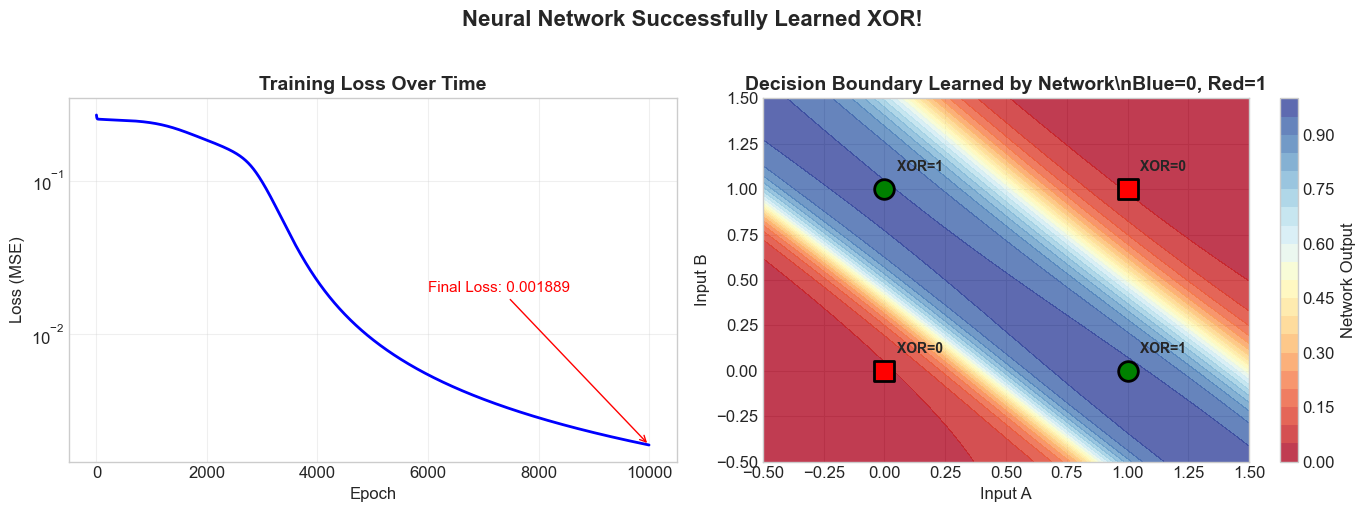

In [54]:
# Visualize training progress and decision boundary
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
ax = axes[0]
ax.plot(losses, 'b-', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss (MSE)')
ax.set_title('Training Loss Over Time', fontsize=14, fontweight='bold')
ax.set_yscale('log')
ax.grid(True, alpha=0.3)
ax.annotate(f'Final Loss: {losses[-1]:.6f}', xy=(len(losses)-1, losses[-1]),
            xytext=(len(losses)*0.6, losses[-1]*10),
            arrowprops=dict(arrowstyle='->', color='red'),
            fontsize=11, color='red')

# Decision boundary
ax = axes[1]
xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 100),
                     np.linspace(-0.5, 1.5, 100))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = nn.predict(grid).reshape(xx.shape)

contour = ax.contourf(xx, yy, Z, levels=20, cmap='RdYlBu', alpha=0.8)
ax.colorbar = plt.colorbar(contour, ax=ax, label='Network Output')

# Plot data points
for i in range(len(X)):
    color = 'green' if y[i] == 1 else 'red'
    marker = 'o' if y[i] == 1 else 's'
    ax.scatter(X[i, 0], X[i, 1], c=color, s=200, edgecolors='black',
               linewidth=2, marker=marker, zorder=5)
    ax.annotate(f'XOR={y[i,0]}', (X[i,0]+0.05, X[i,1]+0.1), fontsize=10, fontweight='bold')

ax.set_xlabel('Input A')
ax.set_ylabel('Input B')
ax.set_title('Decision Boundary Learned by Network\\nBlue=0, Red=1', fontsize=14, fontweight='bold')
ax.set_xlim(-0.5, 1.5)
ax.set_ylim(-0.5, 1.5)

plt.suptitle('Neural Network Successfully Learned XOR!', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---

# Congratulations! You've Mastered NumPy for Deep Learning!

## Summary: What You Learned

| Section | Concept | Deep Learning Application |
|---------|---------|---------------------------|
| 1 | **Arrays & Shapes** | Tensors, data representation, batch dimensions |
| 2 | **Indexing & Slicing** | Batch selection, feature extraction, train/test splits |
| 3 | **Element-wise Operations** | Activation functions (ReLU, Sigmoid, Tanh) |
| 4 | **Broadcasting** | Bias addition, normalization across batches |
| 5 | **Matrix Multiplication** | Forward pass, layer computations |
| 6 | **Statistics & Aggregation** | Loss functions, batch normalization |
| 7 | **Reshaping** | Flattening images, tensor manipulation |
| 8 | **Random Generation** | Weight initialization (He, Xavier) |
| 9 | **Vectorization** | Efficient training (100x speedup!) |
| 10 | **Mini Neural Network** | All concepts working together! |

## What's Next?

Now you're ready for:
1. **`neural_networks_from_scratch.ipynb`** - Build complete neural networks with NumPy
2. **`pytorch_neural_networks_tutorial.ipynb`** - Learn PyTorch with your NumPy foundation
3. **`keras_tensorflow_neural_networks_tutorial.ipynb`** - Master TensorFlow/Keras

## Key Takeaways

1. **Everything in deep learning is arrays (tensors)**
2. **Matrix multiplication is the core operation** (input @ weights + bias)
3. **Broadcasting makes code elegant** (no explicit loops needed)
4. **Vectorization = Speed** (essential for large datasets)
5. **Weight initialization matters** (He init for ReLU, Xavier for tanh/sigmoid)

---

*You now have the NumPy foundation to understand ANY deep learning framework!*